### AMOC reconstruction lat_long

In [11]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION + FEATURE SELECTION
Lat–lon EOFs (depth-mean 0–1000 m), CESM2
----------------------------------------

Inputs:
  EOF_combined_thetao_depthmean_0-1000m.nc
  EOF_combined_so_depthmean_0-1000m.nc
  AMOC_<MODEL>.nc (contains TARGET time series)

Method:
  - Use ensemble-mean PCs: PC_mean(time, mode)
  - Build lagged feature matrix
  - Ridge regression (alpha scan)
  - Feature selection by (var, mode) groups:
      importance = sum(|coef|) over lags
  - Progressive pruning sweep: keep top-K groups

Outputs:
  - Saves baseline + best-compact reconstructions
  - Plots:
      1) R² vs K
      2) Timeseries: truth vs baseline vs compact
      3) EOF maps for selected (var,mode) groups (top-K from best compact)
"""

import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# ============================================================
# CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"  # e.g. "CESM2", "IPSL-CM6A-LR", "MPI-ESM1-2-LR", "EC-Earth3"
TARGET = "AMOC_45N_ensmean"

# Variables to use (set to ["thetao"] or ["so"] if you want single-var)
VARS = ["thetao", "so"]

# Depth interval tag (only affects filenames/output tags)
DEPTH_TAG = "0-1000m"

# Modes/lags
N_MODES = 10
N_LAGS  = 10
TEST_FRAC = 0.2

# Ridge alpha scan
RIDGE_ALPHAS = [0.1, 1, 10, 100, 1000, 1e4, 1e5]

# Progressive pruning sweep:
# Total groups = len(VARS) * N_MODES  (e.g. 2*10 = 20)
K_LIST = [1, 2, 3, 4, 5, 8, 10, 12, 15, 20]

# Paths
EOF_FILES = {
    "thetao": f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/EOF_combined_thetao_depthmean_{DEPTH_TAG}.nc",
    "so":     f"/data/projects/nckf/frekle/EOF_results/{MODEL}/combined_depthmeans/EOF_combined_so_depthmean_{DEPTH_TAG}.nc",
}
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

OUTDIR = f"/data/users/frekle/AMOC_reconstruction/Lat_lon/{MODEL}_{TARGET}/Feature_selection/" + "_".join(VARS) + "_MODESEL/"
os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# HELPERS
# ============================================================

def extract_years_from_time(time_da):
    """
    Robust year extraction from xarray time coordinate:
    - datetime64: uses dt.year
    - numeric CF-time: uses cftime.num2date with units/calendar
    """
    try:
        return xr.DataArray(time_da).dt.year.values.astype(int)
    except Exception:
        vals = np.asarray(time_da.values)
        units = getattr(time_da, "attrs", {}).get("units", None)
        cal   = getattr(time_da, "attrs", {}).get("calendar", "standard")
        if units is None:
            # fallback: try parsing first 4 chars
            return np.array([int(str(v)[:4]) for v in vals], dtype=int)

        import cftime
        dates = cftime.num2date(vals, units=units, calendar=cal)
        return np.array([d.year for d in dates], dtype=int)

def load_eof_file(var):
    f = EOF_FILES[var]
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    return xr.open_dataset(f)

def load_pc_mean(ds, n_modes):
    """
    Return:
      PC(year, mode) as numpy array (T, n_modes)
      years: (T,)
    """
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    if "member" in PC.dims:
        PC = PC.mean("member")
    # PC dims now (time, mode)
    PC = PC.transpose("time", "mode")
    years = extract_years_from_time(ds["time"])
    return PC.values.astype(float), years.astype(int)

def load_amoc(target, ref_years):
    dsA = xr.open_dataset(AMOC_FILE)
    am = dsA[target].squeeze()
    am_years = extract_years_from_time(am["time"])
    # Align by intersection with ref_years
    common = np.intersect1d(ref_years, am_years).astype(int)
    common.sort()
    am_vals = am.values.squeeze()
    am_aligned = am_vals[np.isin(am_years, common)]
    return am_aligned.astype(float), common

def build_X(pc_by_var, years, n_lags, allowed_groups=None):
    """
    pc_by_var[var] = PC array shape (T, n_modes)
    years: (T,)
    allowed_groups: set of (var, mode_index) to keep. If None keep all.
    Returns:
      X: (T-n_lags, n_features)
      feat_map: (n_features, 3) -> (var, lag, mode_index)
      time_out: (T-n_lags,)
    """
    years = np.asarray(years).astype(int)
    T = len(years)

    X = []
    time_out = []
    feat_map = []

    # feature order (fixed):
    # for lag in 0..n_lags-1:
    #   for var in VARS:
    #     for mode in 0..n_modes-1 (if allowed)
    n_modes = next(iter(pc_by_var.values())).shape[1]

    # Build feat_map once (for one row)
    for lag in range(n_lags):
        for var in VARS:
            for m in range(n_modes):
                if (allowed_groups is None) or ((var, m) in allowed_groups):
                    feat_map.append((var, lag, m))
    feat_map = np.array(feat_map, dtype=object)

    # Build X rows
    for t in range(n_lags, T):
        feats = []
        for lag in range(n_lags):
            for var in VARS:
                arr = pc_by_var[var][t - lag, :]  # (n_modes,)
                for m in range(n_modes):
                    if (allowed_groups is None) or ((var, m) in allowed_groups):
                        feats.append(arr[m])
        X.append(feats)
        time_out.append(years[t])

    return np.asarray(X, dtype=float), feat_map, np.asarray(time_out, dtype=int)

def fit_ridge_scan(Xtr, Ytr, Xte, Yte, alphas):
    best = None
    for a in alphas:
        mdl = make_pipeline(StandardScaler(), Ridge(alpha=a))
        mdl.fit(Xtr, Ytr)
        pred_te = mdl.predict(Xte)
        r2 = float(r2_score(Yte, pred_te))
        if best is None or r2 > best["r2"]:
            best = {"alpha": a, "model": mdl, "pred_te": pred_te, "r2": r2}
    best["pred_tr"] = best["model"].predict(Xtr)
    # after scaler, coef are comparable
    coef = best["model"].named_steps["ridge"].coef_
    best["coef"] = np.asarray(coef)
    return best

def summarize_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred))
    r = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true)>0 and np.std(y_pred)>0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true)>0 else np.nan
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    return r2, r, var_ratio, mae, rmse

def group_importance_by_var_mode(coef, feat_map):
    """
    Group by (var, mode), sum |coef| over all lags.
    feat_map columns: (var, lag, mode)
    """
    imp = {}
    coef_abs = np.abs(coef)
    for i in range(len(coef_abs)):
        var, lag, mode = feat_map[i]
        key = (str(var), int(mode))
        imp[key] = imp.get(key, 0.0) + float(coef_abs[i])
    return imp

def plot_eof_map(ax, lon2d, lat2d, eof2d, title=""):
    # pcolormesh handles NaNs OK
    m = ax.pcolormesh(lon2d, lat2d, eof2d, shading="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    plt.colorbar(m, ax=ax, fraction=0.046, pad=0.04)

# ============================================================
# LOAD EOF PCs
# ============================================================

print("Loading EOF PCs (lat–lon depthmean)...")
pc_by_var = {}
years_ref = None
ds_by_var = {}

for var in VARS:
    ds = load_eof_file(var)
    ds_by_var[var] = ds

    PC, yrs = load_pc_mean(ds, N_MODES)
    pc_by_var[var] = PC
    print(f"  ✓ {var} PC shape:", PC.shape)

    if years_ref is None:
        years_ref = yrs
    else:
        # keep intersection if needed
        years_ref = np.intersect1d(years_ref, yrs).astype(int)
        years_ref.sort()

years_ref = np.asarray(years_ref).astype(int)
print(f"Years in EOF PCs: {years_ref[0]}–{years_ref[-1]} (T={len(years_ref)})")

# Make sure PC arrays match years_ref order
for var in VARS:
    # original years for this var
    yrs = extract_years_from_time(ds_by_var[var]["time"]).astype(int)
    pc_by_var[var] = pc_by_var[var][np.isin(yrs, years_ref), :]

# ============================================================
# LOAD AMOC and align years
# ============================================================

print("Loading AMOC...")
AMOC, common_years = load_amoc(TARGET, years_ref)
print(f"✓ Common years: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")

# Also align PCs to common_years
for var in VARS:
    yrs = years_ref
    pc_by_var[var] = pc_by_var[var][np.isin(yrs, common_years), :]

T = len(common_years)

# ============================================================
# BUILD FULL X/Y
# ============================================================

print("Building FULL feature matrix...")
X_full, fmap_full, time_out = build_X(pc_by_var, common_years, N_LAGS, allowed_groups=None)
Y_full = AMOC[N_LAGS:]
print("X_full:", X_full.shape, "Y_full:", Y_full.shape)

# Train/test split
n_train = int((1 - TEST_FRAC) * len(X_full))
Xtr, Xte = X_full[:n_train], X_full[n_train:]
Ytr, Yte = Y_full[:n_train], Y_full[n_train:]
t_test = time_out[n_train:]

# ============================================================
# BASELINE FIT
# ============================================================

print("\nFitting BASELINE (all modes)...")
base = fit_ridge_scan(Xtr, Ytr, Xte, Yte, RIDGE_ALPHAS)
base_alpha = base["alpha"]
base_pred = base["pred_te"]
base_coef = base["coef"]
base_met = summarize_metrics(Yte, base_pred)

print(f"✓ BASE alpha={base_alpha}  R²={base_met[0]:.4f}  corr={base_met[1]:.4f}  var_ratio={base_met[2]:.4f}")

# Save baseline
tag_base = f"{MODEL}_{'_'.join(VARS)}_{TARGET}_latlon_{DEPTH_TAG}_BASE_M{N_MODES}_L{N_LAGS}"
pref_base = os.path.join(OUTDIR, tag_base)
np.save(pref_base + "_Ytrue.npy", Yte.astype(np.float32))
np.save(pref_base + "_Ypred.npy", base_pred.astype(np.float32))
np.save(pref_base + "_Ypred_raw.npy", base_pred.astype(np.float32))
np.save(pref_base + "_time.npy", t_test.astype(int))
np.save(pref_base + "_coef.npy", base_coef.astype(np.float32))
np.save(pref_base + "_feature_map.npy", fmap_full)
np.save(pref_base + "_meta.npy", np.array([base_alpha, *base_met], dtype=float))
np.save(pref_base + "_Xtest.npy", Xte.astype(np.float32))
np.save(pref_base + "_scaler_mean.npy", base["model"].named_steps["standardscaler"].mean_.astype(np.float32))
np.save(pref_base + "_scaler_scale.npy", base["model"].named_steps["standardscaler"].scale_.astype(np.float32))
np.save(pref_base + "_intercept.npy", np.array([base["model"].named_steps["ridge"].intercept_], dtype=np.float32))

# ============================================================
# RANK GROUPS (var, mode)
# ============================================================

imp = group_importance_by_var_mode(base_coef, fmap_full)
ranked = sorted(imp.items(), key=lambda kv: kv[1], reverse=True)

print("\nTop (var, mode) groups by summed |coef| over lags:")
for (key, val) in ranked[:min(20, len(ranked))]:
    var, mode = key
    print(f"  {var:6s} mode{mode+1:02d}  importance={val:.6e}")

rank_arr = np.array([(k[0], int(k[1]), float(v)) for k, v in ranked], dtype=object)
np.save(os.path.join(OUTDIR, f"{MODEL}_{TARGET}_latlon_{DEPTH_TAG}_group_ranking.npy"), rank_arr)

# ============================================================
# SWEEP: KEEP TOP-K GROUPS
# ============================================================

print("\nProgressive pruning sweep...")
sweep_rows = []  # (K, n_features, best_alpha, r2, corr, var_ratio, mae, rmse)

total_groups = len(ranked)
for K in K_LIST:
    K = min(int(K), total_groups)
    topK = set([ranked[i][0] for i in range(K)])  # (var, mode)
    allowed = set([(v, int(m)) for (v, m) in topK])

    Xk, fmap_k, time_out2 = build_X(pc_by_var, common_years, N_LAGS, allowed_groups=allowed)
    Yk = AMOC[N_LAGS:]

    Xtr2, Xte2 = Xk[:n_train], Xk[n_train:]
    Ytr2, Yte2 = Yk[:n_train], Yk[n_train:]

    best = fit_ridge_scan(Xtr2, Ytr2, Xte2, Yte2, RIDGE_ALPHAS)
    pred = best["pred_te"]
    met = summarize_metrics(Yte2, pred)

    sweep_rows.append([K, Xk.shape[1], best["alpha"], *met])
    print(f"  K={K:2d}  feats={Xk.shape[1]:4d}  alpha={best['alpha']:<8g}  R²={met[0]: .4f}  corr={met[1]: .4f}  var={met[2]: .3f}")

sweep = np.array(sweep_rows, dtype=float)
np.save(os.path.join(OUTDIR, f"{MODEL}_{TARGET}_latlon_{DEPTH_TAG}_sweep_metrics.npy"), sweep)

best_idx = int(np.argmax(sweep[:, 3]))  # col 3 is R²
bestK = int(sweep[best_idx, 0])
best_alphaK = float(sweep[best_idx, 2])
best_r2 = float(sweep[best_idx, 3])

print(f"\n✓ Best compact: K={bestK} groups  alpha={best_alphaK}  R²={best_r2:.4f}")

# Refit bestK and save
topK = set([ranked[i][0] for i in range(bestK)])
allowed = set([(v, int(m)) for (v, m) in topK])

Xk, fmap_k, time_out2 = build_X(pc_by_var, common_years, N_LAGS, allowed_groups=allowed)
Yk = AMOC[N_LAGS:]
Xtr2, Xte2 = Xk[:n_train], Xk[n_train:]
Ytr2, Yte2 = Yk[:n_train], Yk[n_train:]
t_test2 = time_out2[n_train:]

best = fit_ridge_scan(Xtr2, Ytr2, Xte2, Yte2, RIDGE_ALPHAS)
predK = best["pred_te"]
coefK = best["coef"]
metK = summarize_metrics(Yte2, predK)

tag_comp = f"{MODEL}_{'_'.join(VARS)}_{TARGET}_latlon_{DEPTH_TAG}_COMPACT_K{bestK}_M{N_MODES}_L{N_LAGS}"
pref_comp = os.path.join(OUTDIR, tag_comp)
np.save(pref_comp + "_Ytrue.npy", Yte2.astype(np.float32))
np.save(pref_comp + "_Ypred.npy", predK.astype(np.float32))
np.save(pref_comp + "_Ypred_raw.npy", predK.astype(np.float32))
np.save(pref_comp + "_time.npy", t_test2.astype(int))
np.save(pref_comp + "_coef.npy", coefK.astype(np.float32))
np.save(pref_comp + "_feature_map.npy", fmap_k)
np.save(pref_comp + "_meta.npy", np.array([best["alpha"], *metK, bestK], dtype=float))
np.save(pref_comp + "_selected_groups.npy", np.array(list(topK), dtype=object))

# --- SAVE COMPACT X_test + scaler params (needed for contribution plots) ---
np.save(pref_comp + "_Xtest.npy", Xte2.astype(np.float32))
np.save(pref_comp + "_scaler_mean.npy",
        best["model"].named_steps["standardscaler"].mean_.astype(np.float32))
np.save(pref_comp + "_scaler_scale.npy",
        best["model"].named_steps["standardscaler"].scale_.astype(np.float32))
np.save(pref_comp + "_intercept.npy",
        np.array([best["model"].named_steps["ridge"].intercept_], dtype=np.float32))



Loading EOF PCs (lat–lon depthmean)...
  ✓ thetao PC shape: (165, 10)
  ✓ so PC shape: (165, 10)
Years in EOF PCs: 1850–2014 (T=165)
Loading AMOC...
✓ Common years: 1850–2014 (T=165)
Building FULL feature matrix...
X_full: (155, 200) Y_full: (155,)

Fitting BASELINE (all modes)...
✓ BASE alpha=10  R²=0.8179  corr=0.9410  var_ratio=0.9274

Top (var, mode) groups by summed |coef| over lags:
  thetao mode03  importance=1.614344e-01
  so     mode02  importance=1.567699e-01
  so     mode03  importance=1.459447e-01
  thetao mode10  importance=1.304427e-01
  thetao mode05  importance=1.277830e-01
  so     mode04  importance=1.265939e-01
  thetao mode04  importance=1.113708e-01
  thetao mode07  importance=1.082546e-01
  so     mode10  importance=1.072022e-01
  so     mode09  importance=1.028919e-01
  so     mode07  importance=9.970727e-02
  thetao mode02  importance=9.447524e-02
  so     mode05  importance=9.051633e-02
  thetao mode08  importance=8.647067e-02
  thetao mode06  importance=7.6605

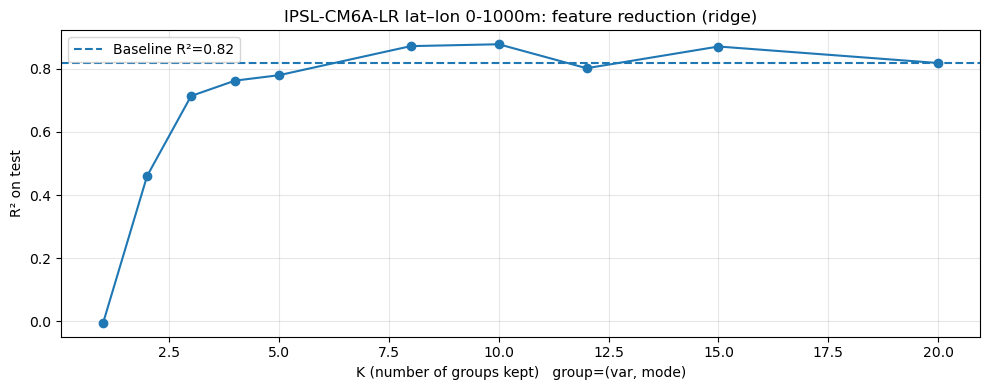

Saved: /data/users/frekle/AMOC_reconstruction/Lat_lon/IPSL-CM6A-LR_AMOC_45N_ensmean/Feature_selection/thetao_so_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_latlon_0-1000m_R2_vs_K.png


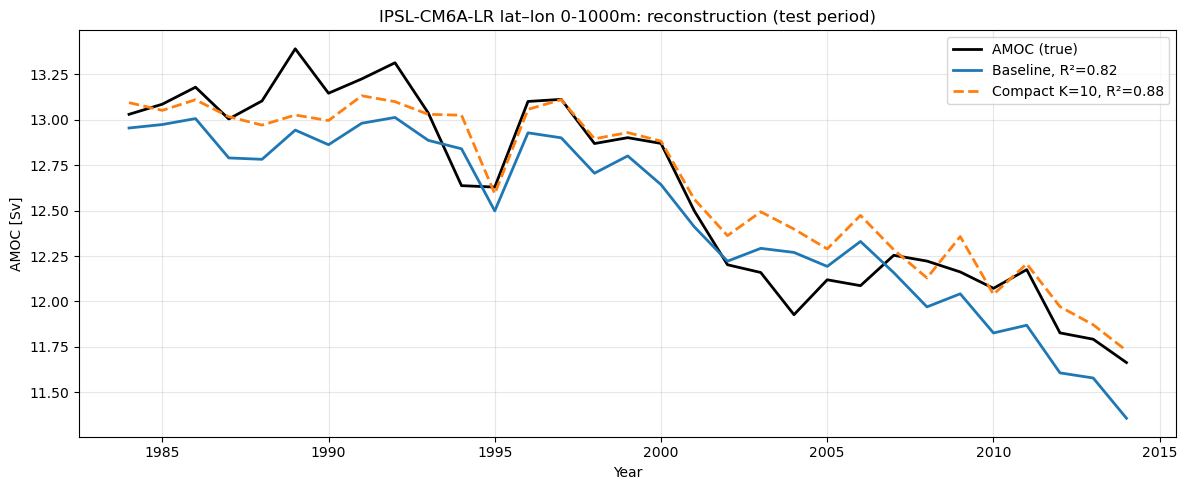

Saved: /data/users/frekle/AMOC_reconstruction/Lat_lon/IPSL-CM6A-LR_AMOC_45N_ensmean/Feature_selection/thetao_so_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_latlon_0-1000m_timeseries_baseline_vs_compact.png


/tmp/ipykernel_866360/33559224.py:213: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(lon2d, lat2d, eof2d, shading="auto")


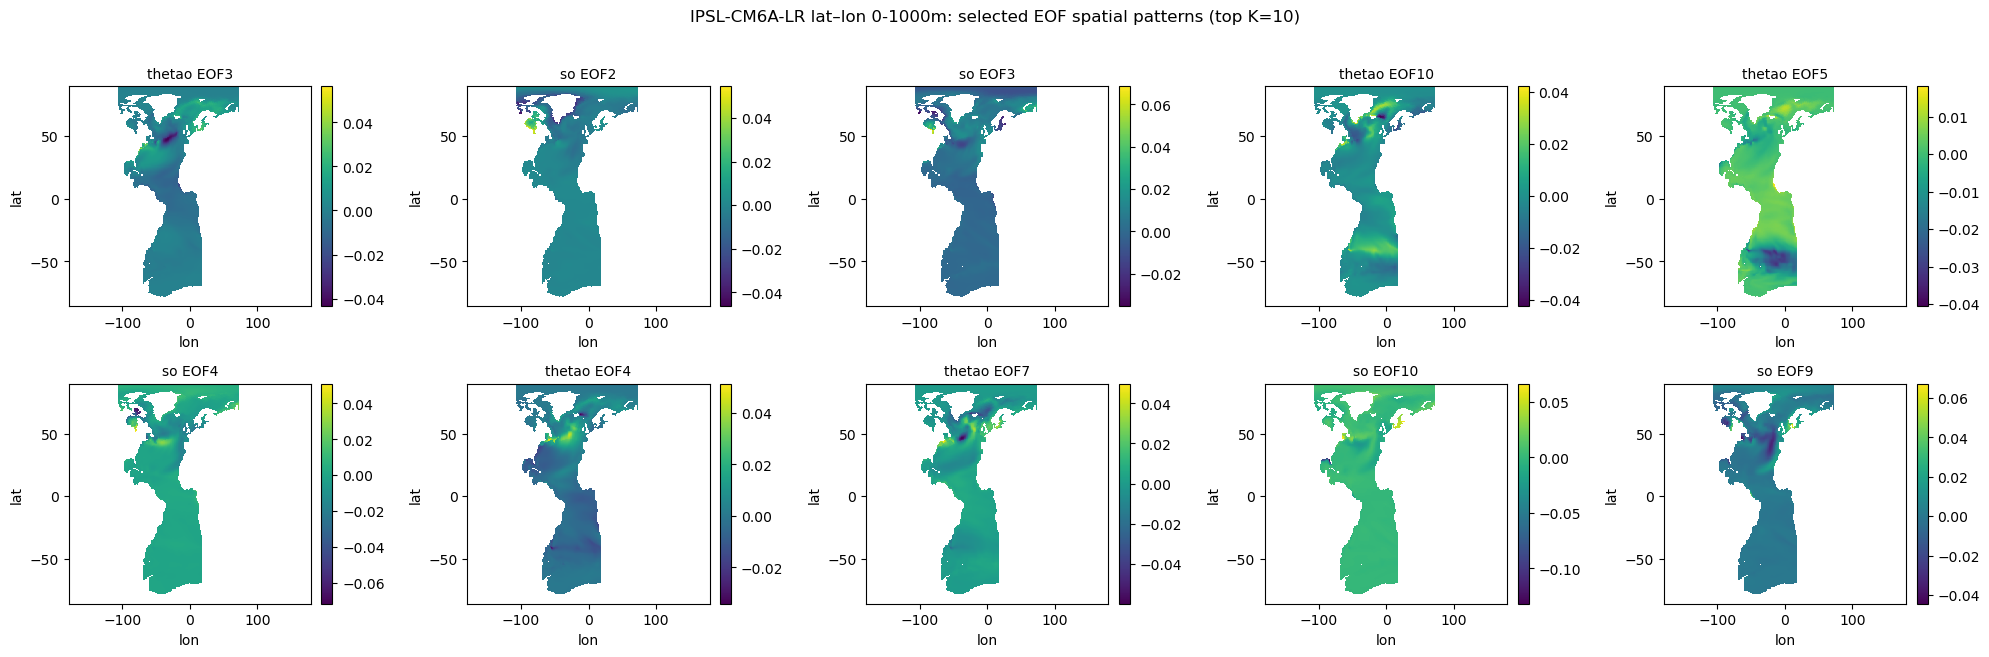

Saved: /data/users/frekle/AMOC_reconstruction/Lat_lon/IPSL-CM6A-LR_AMOC_45N_ensmean/Feature_selection/thetao_so_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_latlon_0-1000m_selected_EOF_maps_K10.png

✅ DONE.
Baseline prefix: /data/users/frekle/AMOC_reconstruction/Lat_lon/IPSL-CM6A-LR_AMOC_45N_ensmean/Feature_selection/thetao_so_MODESEL/IPSL-CM6A-LR_thetao_so_AMOC_45N_ensmean_latlon_0-1000m_BASE_M10_L10
Compact  prefix: /data/users/frekle/AMOC_reconstruction/Lat_lon/IPSL-CM6A-LR_AMOC_45N_ensmean/Feature_selection/thetao_so_MODESEL/IPSL-CM6A-LR_thetao_so_AMOC_45N_ensmean_latlon_0-1000m_COMPACT_K10_M10_L10


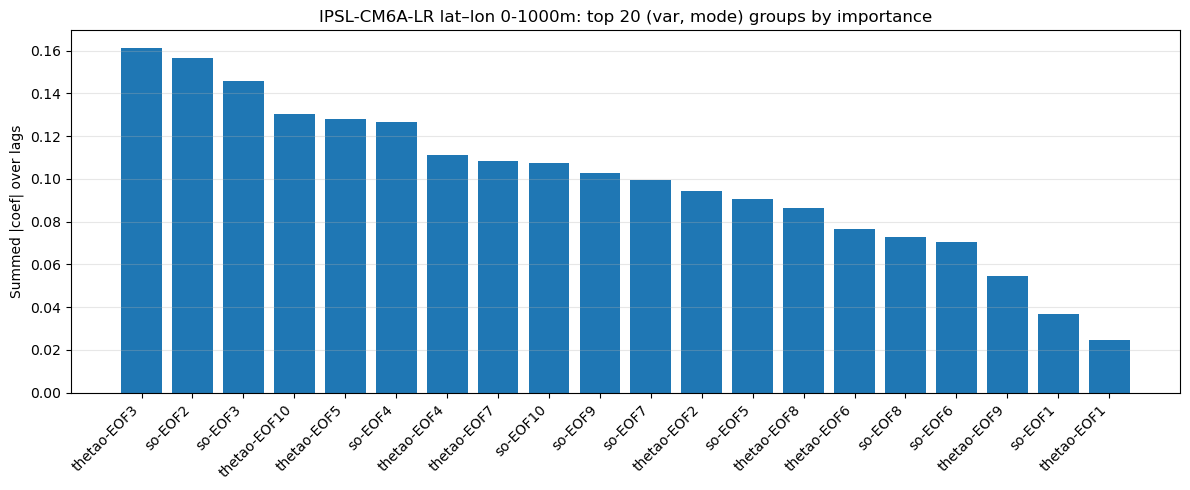

Saved: /data/users/frekle/AMOC_reconstruction/Lat_lon/IPSL-CM6A-LR_AMOC_45N_ensmean/Feature_selection/thetao_so_MODESEL/IPSL-CM6A-LR_AMOC_45N_ensmean_latlon_0-1000m_top20_group_importance.png


In [12]:
# ============================================================
# PLOTS
# ============================================================

# 1) R² vs K
plt.figure(figsize=(10, 4))
plt.plot(sweep[:, 0], sweep[:, 3], marker="o")
plt.axhline(base_met[0], linestyle="--", label=f"Baseline R²={base_met[0]:.2f}")
plt.xlabel("K (number of groups kept)   group=(var, mode)")
plt.ylabel("R² on test")
plt.title(f"{MODEL} lat–lon {DEPTH_TAG}: feature reduction (ridge)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f1 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_latlon_{DEPTH_TAG}_R2_vs_K.png")
plt.savefig(f1, dpi=300)
plt.show()
print("Saved:", f1)

# 2) Timeseries comparison: true vs baseline vs compact
plt.figure(figsize=(12, 5))
plt.plot(t_test, Yte, lw=2, color="black", label="AMOC (true)")
plt.plot(t_test, base_pred, lw=2, label=f"Baseline, R²={base_met[0]:.2f}")
plt.plot(t_test2, predK, lw=2, linestyle="--", label=f"Compact K={bestK}, R²={metK[0]:.2f}")
plt.xlabel("Year")
plt.ylabel("AMOC [Sv]")
plt.title(f"{MODEL} lat–lon {DEPTH_TAG}: reconstruction (test period)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
f2 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_latlon_{DEPTH_TAG}_timeseries_baseline_vs_compact.png")
plt.savefig(f2, dpi=300)
plt.show()
print("Saved:", f2)

# 3) EOF maps for selected groups (bestK)
# Load lon/lat from one of the datasets (same grid for both vars in CESM2 combined results)
lon2d = ds_by_var[VARS[0]]["lon"].values
lat2d = ds_by_var[VARS[0]]["lat"].values

# Sort selected groups by importance order (ranked list)
selected_ranked = [ranked[i][0] for i in range(bestK)]  # (var, mode)
ncols = min(5, bestK)
nrows = int(np.ceil(bestK / ncols))

plt.figure(figsize=(4*ncols, 3.2*nrows))
for i, (var, mode) in enumerate(selected_ranked):
    ax = plt.subplot(nrows, ncols, i+1)
    EOF = ds_by_var[var]["EOF"].isel(mode=int(mode)).values  # (y,x)
    plot_eof_map(ax, lon2d, lat2d, EOF, title=f"{var} EOF{int(mode)+1}")

plt.suptitle(f"{MODEL} lat–lon {DEPTH_TAG}: selected EOF spatial patterns (top K={bestK})", y=1.02)
plt.tight_layout()
f3 = os.path.join(OUTDIR, f"{MODEL}_{TARGET}_latlon_{DEPTH_TAG}_selected_EOF_maps_K{bestK}.png")
plt.savefig(f3, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", f3)

print("\n✅ DONE.")
print("Baseline prefix:", pref_base)
print("Compact  prefix:", pref_comp)

# ============================================================
# BAR PLOT — TOP (var, mode) GROUPS (lat–lon)
# ============================================================

topN = min(20, len(ranked))

labels = [f"{var}-EOF{mode+1}" for ((var, mode), _) in ranked[:topN]]
vals   = [val for (_, val) in ranked[:topN]]

plt.figure(figsize=(12, 5))
plt.bar(range(topN), vals)
plt.xticks(range(topN), labels, rotation=45, ha="right")
plt.ylabel("Summed |coef| over lags")
plt.title(f"{MODEL} lat–lon {DEPTH_TAG}: top {topN} (var, mode) groups by importance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

f_bar = os.path.join(
    OUTDIR,
    f"{MODEL}_{TARGET}_latlon_{DEPTH_TAG}_top{topN}_group_importance.png"
)
plt.show()

print("Saved:", f_bar)
